# Get Data

### Get Fashion MNIST

In [48]:
# Obtain the fmnist dataset and prepare it for training.
import torch
import torch.nn.functional as F
import torchvision
from torchvision import datasets, transforms
import numpy as np
from matplotlib import pyplot as plt

# Import the current dataset (should be similar in shape to MNIST).
current_train_data = np.load('./Datasets/Images/Training_Dataset.npy')
current_train_labels = np.load('./Datasets/Labels/Training_Dataset.npy')

# Print out the shapes to verify.
print(f'Current training data shape: {current_train_data.shape}')        # Should be (60000, 1, 28, 28)
print(f'Current training labels shape: {current_train_labels.shape}')    # Should be (60000, 10)

# Print min and max values to verify normalization.
print(f'Current training data min/max: {np.min(current_train_data)}/{np.max(current_train_data)}')

# Load the Fashion-MNIST dataset with transformations that convert the labels to one-hot encoding.
train_dataset = torchvision.datasets.FashionMNIST(root='./data/', train=True,
                                 transform=torchvision.transforms.ToTensor(),
                                 target_transform=torchvision.transforms.Compose([
                                 lambda x:torch.LongTensor([x]), # or just torch.tensor
                                 lambda x:F.one_hot(x,10)]),
                                 download=True)

test_dataset = torchvision.datasets.FashionMNIST(root='./data/', train=False,
                                 transform=torchvision.transforms.ToTensor(),
                                 target_transform=torchvision.transforms.Compose([
                                 lambda x:torch.LongTensor([x]), # or just torch.tensor
                                 lambda x:F.one_hot(x,10)]),
                                 download=True)

# Print the min and max values of the Fashion-MNIST dataset before normalization.
sample_data, _ = train_dataset[0]
print(f'Fashion-MNIST sample data min/max before normalization: {torch.min(sample_data)}/{torch.max(sample_data)}')


# Get all the training data and labels as tensors.
train_data = torch.stack([data for data, _ in train_dataset]).float()
train_labels = torch.stack([label for _, label in train_dataset])

# Split the test dataset into validation and test sets.
val_size = 5000
test_size = len(test_dataset) - val_size
generator = torch.Generator().manual_seed(42)
val_dataset, test_dataset = torch.utils.data.random_split(test_dataset, [val_size, test_size], generator=generator)
val_data = torch.stack([data for data, _ in val_dataset]).float()
val_labels = torch.stack([label for _, label in val_dataset])
test_data = torch.stack([data for data, _ in test_dataset]).float()
test_labels = torch.stack([label for _, label in test_dataset])

# Print out the shapes to verify.
print(f'Training data shape: {train_data.shape}')        # Should be (60000, 1, 28, 28)
print(f'Training labels shape: {train_labels.shape}')    # Should be (60000, 1, 10)

# Print out validation and test shapes to verify.
print(f'Validation data shape: {val_data.shape}')        # Should be (5000, 1, 28, 28)
print(f'Validation labels shape: {val_labels.shape}')    # Should be (5000, 1, 10)
print(f'Test data shape: {test_data.shape}')            # Should be (5000, 1, 28, 28)
print(f'Test labels shape: {test_labels.shape}')        # Should be (5000, 1, 10)

# Print the min and max values to verify normalization.
print(f'Training data min/max: {torch.min(train_data)}/{torch.max(train_data)}')
print(f'Validation data min/max: {torch.min(val_data)}/{torch.max(val_data)}')
print(f'Test data min/max: {torch.min(test_data)}/{torch.max(test_data)}')


Current training data shape: (60000, 1, 28, 28)
Current training labels shape: (60000, 1, 10)
Current training data min/max: 0.0/1.0
Fashion-MNIST sample data min/max before normalization: 0.0/1.0
Training data shape: torch.Size([60000, 1, 28, 28])
Training labels shape: torch.Size([60000, 1, 10])
Validation data shape: torch.Size([5000, 1, 28, 28])
Validation labels shape: torch.Size([5000, 1, 10])
Test data shape: torch.Size([5000, 1, 28, 28])
Test labels shape: torch.Size([5000, 1, 10])
Training data min/max: 0.0/1.0
Validation data min/max: 0.0/1.0
Test data min/max: 0.0/1.0


torch.Size([1, 1, 28, 28]) torch.Size([1, 1, 28, 28]) torch.Size([1, 1, 28, 28])
tensor(0.) tensor(0.9993) tensor(0.) tensor(0.9993) tensor(0.) tensor(0.9992)
tensor([0.0000, 0.3330, 0.6660, 1.0000]) tensor([0.0000, 0.3330, 0.6660, 1.0000]) tensor([0.0000, 0.3330, 0.6660, 1.0000])


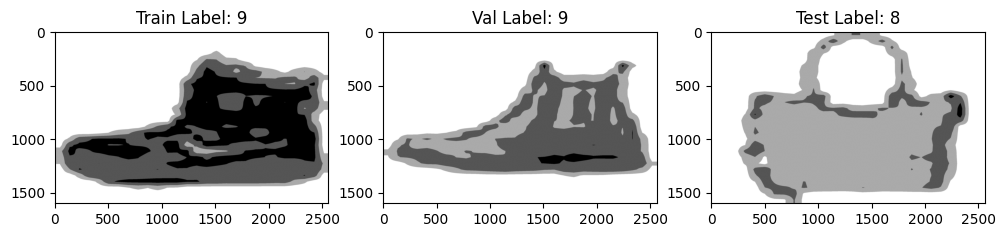

In [47]:
# Resize the image to 2560x1600 using bilinear interpolation

train_image_1 = train_data[0].unsqueeze(0)  # Add batch dimension and channel dimension
val_image_1 = val_data[0].unsqueeze(0)      # Add batch dimension and channel dimension
test_image_1 = test_data[0].unsqueeze(0)    # Add batch dimension and channel dimension

print(train_image_1.shape, val_image_1.shape, test_image_1.shape)

train_image_1 = torchvision.transforms.Resize((1600, 2560))(train_image_1)
val_image_1 = torchvision.transforms.Resize((1600, 2560))(val_image_1)
test_image_1 = torchvision.transforms.Resize((1600, 2560))(test_image_1)

print(
    torch.min(train_image_1), torch.max(train_image_1),
    torch.min(val_image_1), torch.max(val_image_1),
    torch.min(test_image_1), torch.max(test_image_1)
)

def posterize_image(image):
    # image assumed normalized to [0,1]
    # 4-level posterization using threshold logic only.

    # Compute threshold boundaries that split the ranges
    # midpoints between levels:
    # between l0 and l1: 1/6
    # between l1 and l2: 1/2
    # between l2 and l3: 5/6
    t1 = 1/6
    t2 = 1/2
    t3 = 5/6

    # Initialize output
    out = torch.empty_like(image)

    # Apply level assignment
    out[image <  t1] = 0.0
    out[(image >= t1) & (image <  t2)] = 0.333
    out[(image >= t2) & (image <  t3)] = 0.666
    out[image >= t3] = 1.0

    return out

train_image_1 = posterize_image(1.0 - train_image_1)
val_image_1 = posterize_image(1.0 - val_image_1)
test_image_1 = posterize_image(1.0 - test_image_1)

# Print the number of unique values in the posterized images
print(
    torch.unique(train_image_1),
    torch.unique(val_image_1),
    torch.unique(test_image_1)
)

fig, axs = plt.subplots(1, 3, figsize=(12, 4))
axs[0].imshow(train_image_1.squeeze(), cmap='gray')
axs[0].set_title(f'Train Label: {torch.argmax(train_labels[0]).item()}')
axs[1].imshow(val_image_1.squeeze(), cmap='gray')
axs[1].set_title(f'Val Label: {torch.argmax(val_labels[0]).item()}')
axs[2].imshow(test_image_1.squeeze(), cmap='gray')
axs[2].set_title(f'Test Label: {torch.argmax(test_labels[0]).item()}')
plt.show()

In [ ]:
# Find the image where we have the least amount of 

In [28]:
# Assert that the data types are the same as original dataset for all datasets

# Convert to numpy
train_data = train_data.numpy()
train_labels = train_labels.numpy()
val_data = val_data.numpy()
val_labels = val_labels.numpy()
test_data = test_data.numpy()
test_labels = test_labels.numpy()

assert train_data.dtype == current_train_data.dtype, f"Data types do not match!: train_data dtype={train_data.dtype}, expected dtype={current_train_data.dtype}"
assert train_labels.dtype == current_train_labels.dtype, f"Label data types do not match!: train_labels dtype={train_labels.dtype}, expected dtype={current_train_labels.dtype}"
assert val_data.dtype == current_train_data.dtype, f"Data types do not match!: val_data dtype={val_data.dtype}, expected dtype={current_train_data.dtype}"
assert val_labels.dtype == current_train_labels.dtype, f"Label data types do not match!: val_labels dtype={val_labels.dtype}, expected dtype={current_train_labels.dtype}"
assert test_data.dtype == current_train_data.dtype, f"Data types do not match!: test_data dtype={test_data.dtype}, expected dtype={current_train_data.dtype}"
assert test_labels.dtype == current_train_labels.dtype, f"Label data types do not match!: test_labels dtype={test_labels.dtype}, expected dtype={current_train_labels.dtype}"


In [29]:
# Save data as .npy with appropriate names into FashionDatasets folder.
ImageDir = './FashionDatasets/Images/'
LabelDir = './FashionDatasets/Labels/'
np.save(ImageDir + 'Training_Dataset.npy', train_data)
np.save(LabelDir + 'Training_Dataset.npy', train_labels)
np.save(ImageDir + 'Validation_Dataset.npy', val_data)
np.save(LabelDir + 'Validation_Dataset.npy', val_labels)
np.save(ImageDir + 'Test_Dataset.npy', test_data)
np.save(LabelDir + 'Test_Dataset.npy', test_labels)

### Get Kuzushiji MNIST

In [1]:
# Obtain the fmnist dataset and prepare it for training.
import torch
import torch.nn.functional as F
import torchvision
from torchvision import datasets, transforms
import numpy as np
from matplotlib import pyplot as plt

# Import the current dataset (should be similar in shape to MNIST).
current_train_data = np.load('./Datasets/Images/Training_Dataset.npy')
current_train_labels = np.load('./Datasets/Labels/Training_Dataset.npy')

# Print out the shapes to verify.
print(f'Current training data shape: {current_train_data.shape}')        # Should be (60000, 1, 28, 28)
print(f'Current training labels shape: {current_train_labels.shape}')    # Should be (60000, 10)

# Print min and max values to verify normalization.
print(f'Current training data min/max: {np.min(current_train_data)}/{np.max(current_train_data)}')

# Load the Fashion-MNIST dataset with transformations that convert the labels to one-hot encoding.
train_dataset = torchvision.datasets.KMNIST(root='./data/', train=True,
                                 transform=torchvision.transforms.ToTensor(),
                                 target_transform=torchvision.transforms.Compose([
                                 lambda x:torch.LongTensor([x]), # or just torch.tensor
                                 lambda x:F.one_hot(x,10)]),
                                 download=True)

test_dataset = torchvision.datasets.KMNIST(root='./data/', train=False,
                                 transform=torchvision.transforms.ToTensor(),
                                 target_transform=torchvision.transforms.Compose([
                                 lambda x:torch.LongTensor([x]), # or just torch.tensor
                                 lambda x:F.one_hot(x,10)]),
                                 download=True)

# Print the min and max values of the Fashion-MNIST dataset before normalization.
sample_data, _ = train_dataset[0]
print(f'Fashion-MNIST sample data min/max before normalization: {torch.min(sample_data)}/{torch.max(sample_data)}')


# Get all the training data and labels as tensors.
train_data = torch.stack([data for data, _ in train_dataset]).float()
train_labels = torch.stack([label for _, label in train_dataset])

# Split the test dataset into validation and test sets.
val_size = 5000
test_size = len(test_dataset) - val_size
generator = torch.Generator().manual_seed(42)
val_dataset, test_dataset = torch.utils.data.random_split(test_dataset, [val_size, test_size], generator=generator)
val_data = torch.stack([data for data, _ in val_dataset]).float()
val_labels = torch.stack([label for _, label in val_dataset])
test_data = torch.stack([data for data, _ in test_dataset]).float()
test_labels = torch.stack([label for _, label in test_dataset])

# Print out the shapes to verify.
print(f'Training data shape: {train_data.shape}')        # Should be (60000, 1, 28, 28)
print(f'Training labels shape: {train_labels.shape}')    # Should be (60000, 1, 10)

# Print out validation and test shapes to verify.
print(f'Validation data shape: {val_data.shape}')        # Should be (5000, 1, 28, 28)
print(f'Validation labels shape: {val_labels.shape}')    # Should be (5000, 1, 10)
print(f'Test data shape: {test_data.shape}')            # Should be (5000, 1, 28, 28)
print(f'Test labels shape: {test_labels.shape}')        # Should be (5000, 1, 10)

# Print the min and max values to verify normalization.
print(f'Training data min/max: {torch.min(train_data)}/{torch.max(train_data)}')
print(f'Validation data min/max: {torch.min(val_data)}/{torch.max(val_data)}')
print(f'Test data min/max: {torch.min(test_data)}/{torch.max(test_data)}')

Current training data shape: (60000, 1, 28, 28)
Current training labels shape: (60000, 1, 10)
Current training data min/max: 0.0/1.0


100%|██████████| 18.2M/18.2M [00:12<00:00, 1.47MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 205kB/s]
100%|██████████| 3.04M/3.04M [00:02<00:00, 1.51MB/s]
100%|██████████| 5.12k/5.12k [00:00<00:00, 4.61MB/s]


Fashion-MNIST sample data min/max before normalization: 0.0/1.0
Training data shape: torch.Size([60000, 1, 28, 28])
Training labels shape: torch.Size([60000, 1, 10])
Validation data shape: torch.Size([5000, 1, 28, 28])
Validation labels shape: torch.Size([5000, 1, 10])
Test data shape: torch.Size([5000, 1, 28, 28])
Test labels shape: torch.Size([5000, 1, 10])
Training data min/max: 0.0/1.0
Validation data min/max: 0.0/1.0
Test data min/max: 0.0/1.0


torch.Size([1, 1, 28, 28]) torch.Size([1, 1, 28, 28]) torch.Size([1, 1, 28, 28])
tensor(0.) tensor(1.) tensor(0.) tensor(1.) tensor(0.) tensor(1.)
tensor([0., 1.]) tensor([0., 1.]) tensor([0., 1.])


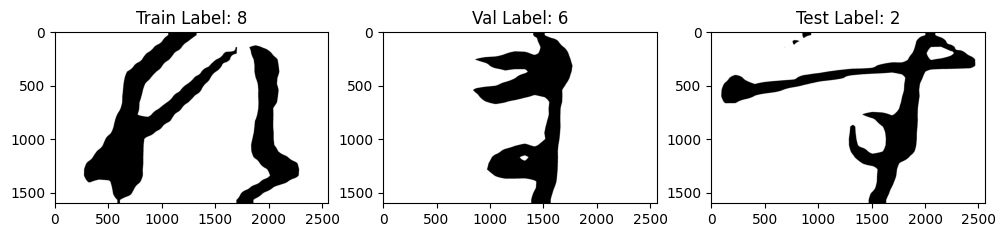

In [4]:
# Resize the image to 2560x1600 using bilinear interpolation

train_image_1 = train_data[0].unsqueeze(0)  # Add batch dimension and channel dimension
val_image_1 = val_data[0].unsqueeze(0)      # Add batch dimension and channel dimension
test_image_1 = test_data[0].unsqueeze(0)    # Add batch dimension and channel dimension

print(train_image_1.shape, val_image_1.shape, test_image_1.shape)

train_image_1 = torchvision.transforms.Resize((1600, 2560))(train_image_1)
val_image_1 = torchvision.transforms.Resize((1600, 2560))(val_image_1)
test_image_1 = torchvision.transforms.Resize((1600, 2560))(test_image_1)

print(
    torch.min(train_image_1), torch.max(train_image_1),
    torch.min(val_image_1), torch.max(val_image_1),
    torch.min(test_image_1), torch.max(test_image_1)
)

def threshold_image(image, threshold=0.5):
    return (image > threshold).float()


def posterize_image(image):
    # image assumed normalized to [0,1]
    # 4-level posterization using threshold logic only.

    # Compute threshold boundaries that split the ranges
    # midpoints between levels:
    # between l0 and l1: 1/6
    # between l1 and l2: 1/2
    # between l2 and l3: 5/6
    t1 = 1/6
    t2 = 1/2
    t3 = 5/6

    # Initialize output
    out = torch.empty_like(image)

    # Apply level assignment
    out[image <  t1] = 0.0
    out[(image >= t1) & (image <  t2)] = 0.333
    out[(image >= t2) & (image <  t3)] = 0.666
    out[image >= t3] = 1.0

    return out

#train_image_1 = posterize_image(1.0 - train_image_1)
#val_image_1 = posterize_image(1.0 - val_image_1)
#test_image_1 = posterize_image(1.0 - test_image_1)
train_image_1 =threshold_image(1.0 - train_image_1)
val_image_1 =threshold_image(1.0 - val_image_1)
test_image_1 =threshold_image(1.0 - test_image_1)

# Print the number of unique values in the posterized images
print(
    torch.unique(train_image_1),
    torch.unique(val_image_1),
    torch.unique(test_image_1)
)

fig, axs = plt.subplots(1, 3, figsize=(12, 4))
axs[0].imshow(train_image_1.squeeze(), cmap='gray')
axs[0].set_title(f'Train Label: {torch.argmax(train_labels[0]).item()}')
axs[1].imshow(val_image_1.squeeze(), cmap='gray')
axs[1].set_title(f'Val Label: {torch.argmax(val_labels[0]).item()}')
axs[2].imshow(test_image_1.squeeze(), cmap='gray')
axs[2].set_title(f'Test Label: {torch.argmax(test_labels[0]).item()}')
plt.show()

In [5]:
# Assert that the data types are the same as original dataset for all datasets

# Convert to numpy
train_data = train_data.numpy()
train_labels = train_labels.numpy()
val_data = val_data.numpy()
val_labels = val_labels.numpy()
test_data = test_data.numpy()
test_labels = test_labels.numpy()

assert train_data.dtype == current_train_data.dtype, f"Data types do not match!: train_data dtype={train_data.dtype}, expected dtype={current_train_data.dtype}"
assert train_labels.dtype == current_train_labels.dtype, f"Label data types do not match!: train_labels dtype={train_labels.dtype}, expected dtype={current_train_labels.dtype}"
assert val_data.dtype == current_train_data.dtype, f"Data types do not match!: val_data dtype={val_data.dtype}, expected dtype={current_train_data.dtype}"
assert val_labels.dtype == current_train_labels.dtype, f"Label data types do not match!: val_labels dtype={val_labels.dtype}, expected dtype={current_train_labels.dtype}"
assert test_data.dtype == current_train_data.dtype, f"Data types do not match!: test_data dtype={test_data.dtype}, expected dtype={current_train_data.dtype}"
assert test_labels.dtype == current_train_labels.dtype, f"Label data types do not match!: test_labels dtype={test_labels.dtype}, expected dtype={current_train_labels.dtype}"


In [6]:
# Save data as .npy with appropriate names into KuzushijiDataset folder.
ImageDir = './KuzushijiDataset/Images/'
LabelDir = './KuzushijiDataset/Labels/'
np.save(ImageDir + 'Training_Dataset.npy', train_data)
np.save(LabelDir + 'Training_Dataset.npy', train_labels)
np.save(ImageDir + 'Validation_Dataset.npy', val_data)
np.save(LabelDir + 'Validation_Dataset.npy', val_labels)
np.save(ImageDir + 'Test_Dataset.npy', test_data)
np.save(LabelDir + 'Test_Dataset.npy', test_labels)

# Get Tissue MNIST

In [ ]:
from medmnist import OCTMNIST, DermaMNIST, OrganAMNIST, VesselMNIST3D
from matplotlib import pyplot as plt
import torch
import torchvision.transforms as transforms
import torchvision
import numpy as np
#train_dataset = OCTMNIST(split="train", download=True)
#val_dataset = OCTMNIST(split="val", download=True)
#train_dataset = DermaMNIST(split="train", download=True)
#val_dataset = DermaMNIST(split="val", download=True)
train_dataset = OrganAMNIST(split="train", download=True)
val_dataset = OrganAMNIST(split="val", download=True)
#train_dataset = VesselMNIST3D(split="train", download=True)
#val_dataset = VesselMNIST3D(split="val", download=True)

# Load MNIST dataset
#train_dataset = np.load('./Datasets/Images/Training_Dataset.npy')
#train_labels  = np.load('./Datasets/Labels/Training_Dataset.npy')
#train_labels  = np.argmax(train_labels, axis=-1).squeeze()

# Load Fashion-MNIST dataset
train_dataset = np.load('./FashionDatasets/Images/Training_Dataset.npy')
train_labels  = np.load('./FashionDatasets/Labels/Training_Dataset.npy')
train_labels  = np.argmax(train_labels, axis=-1).squeeze()

# Kuzushiji-MNIST dataset
#train_dataset = np.load('./KuzushijiDataset/Images/Training_Dataset.npy')
#train_labels  = np.load('./KuzushijiDataset/Labels/Training_Dataset.npy')
#train_labels  = np.argmax(train_labels, axis=-1).squeeze()

# To tensor
train_data = torch.from_numpy(train_dataset).float()
train_labels = torch.from_numpy(train_labels).long()



In [116]:

# Turn PIL image to tensor for all images
# Results in [N, 1, 28, 28] tensors

try:
    train_data = torch.stack([transforms.ToTensor()(image) for image, _ in train_dataset])
except:
    train_data = torch.stack([torch.tensor(data) for data, _ in train_dataset]).float()
    train_data = train_data.squeeze()
train_labels = np.stack([label for _, label in train_dataset])
train_labels = torch.tensor(train_labels).squeeze()



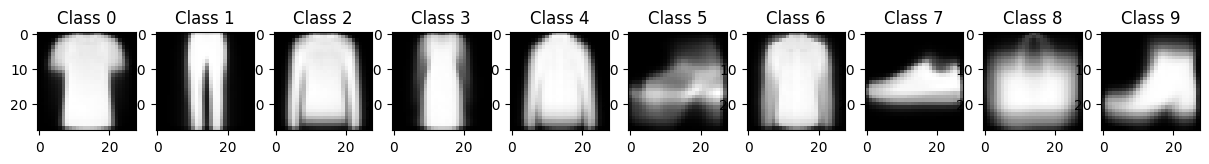

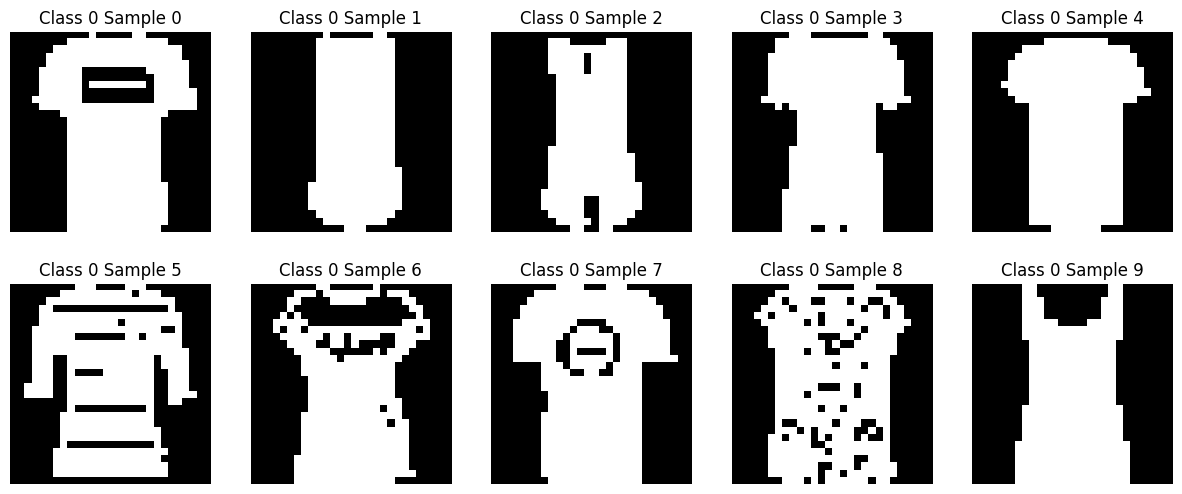

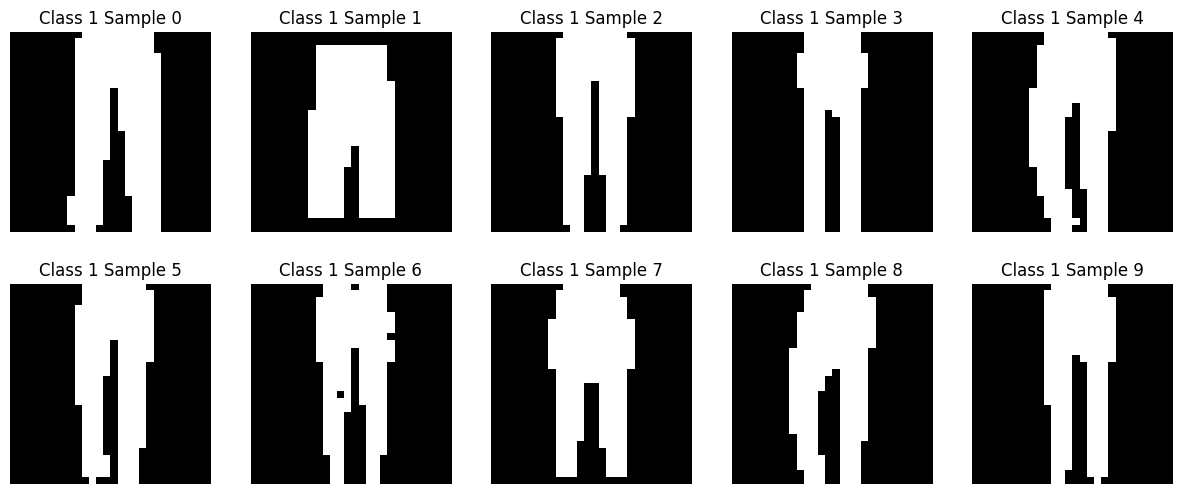

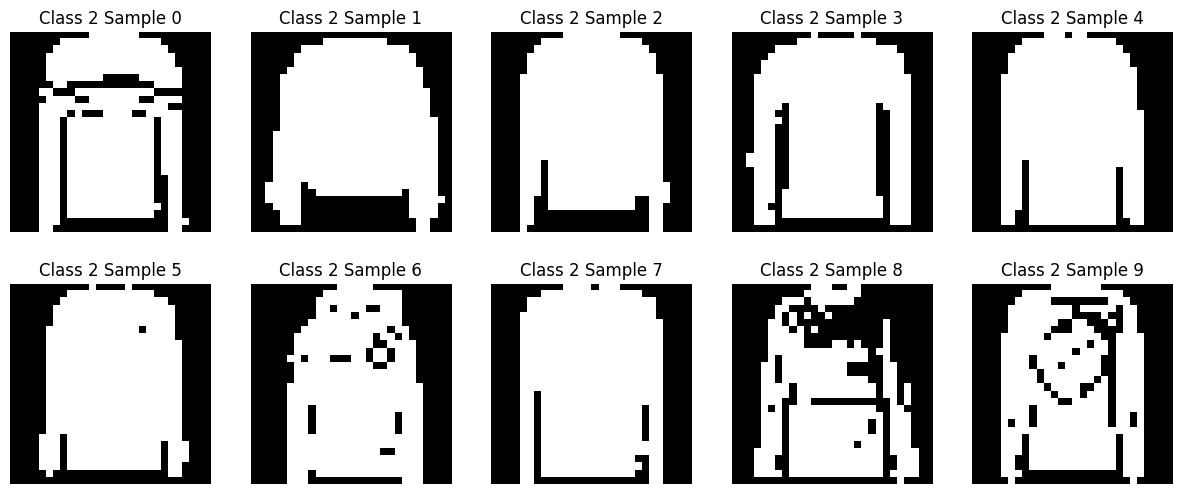

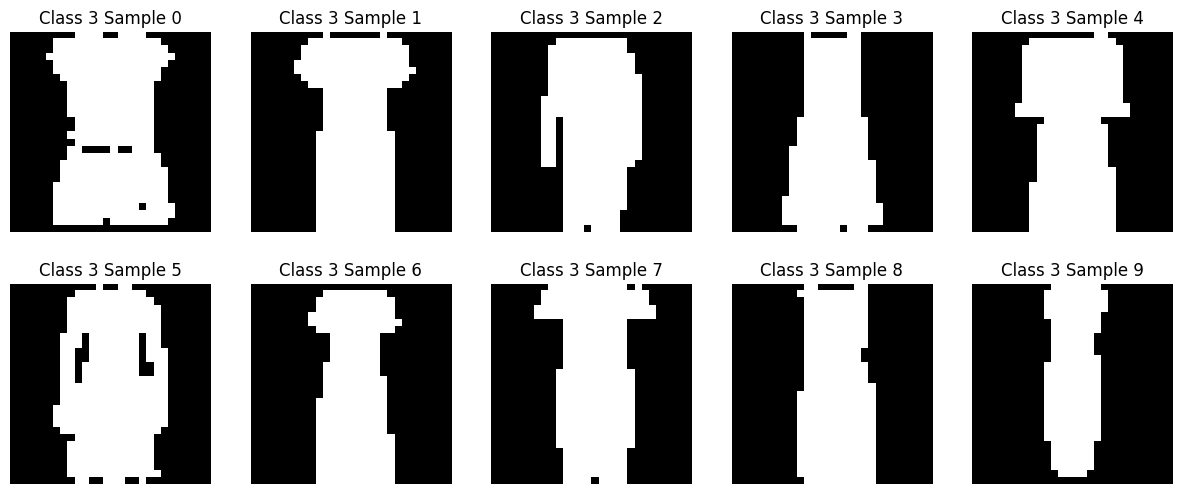

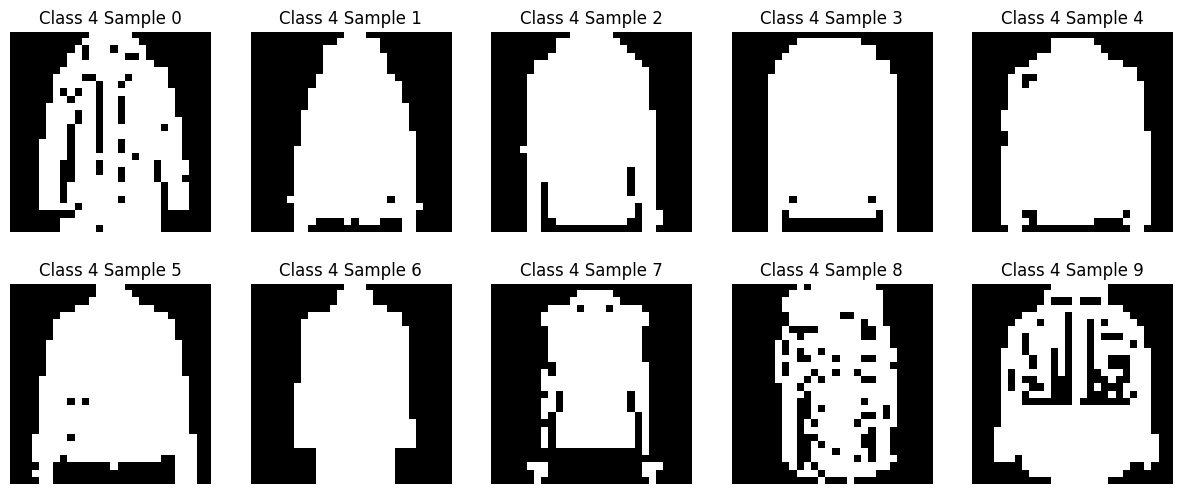

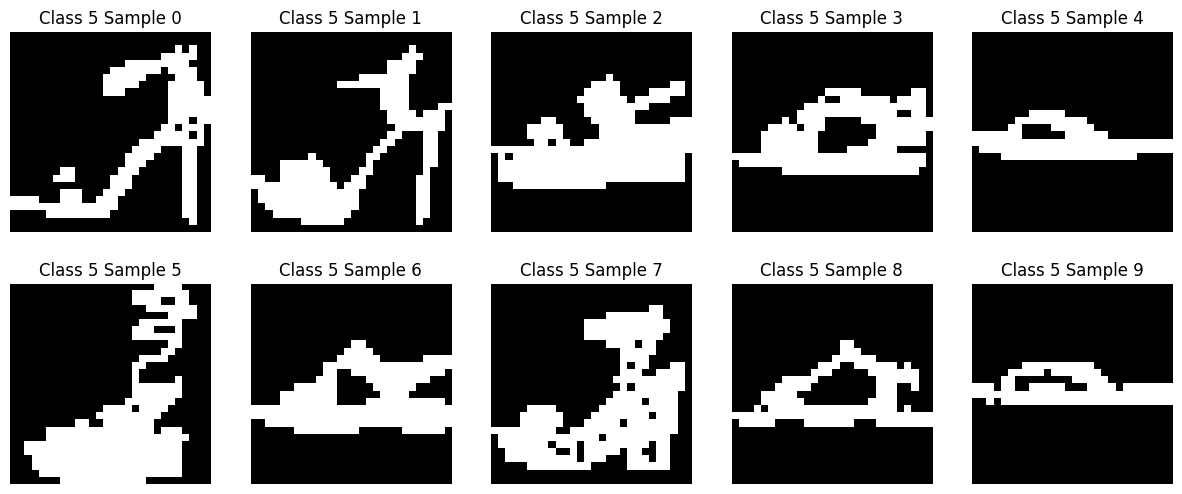

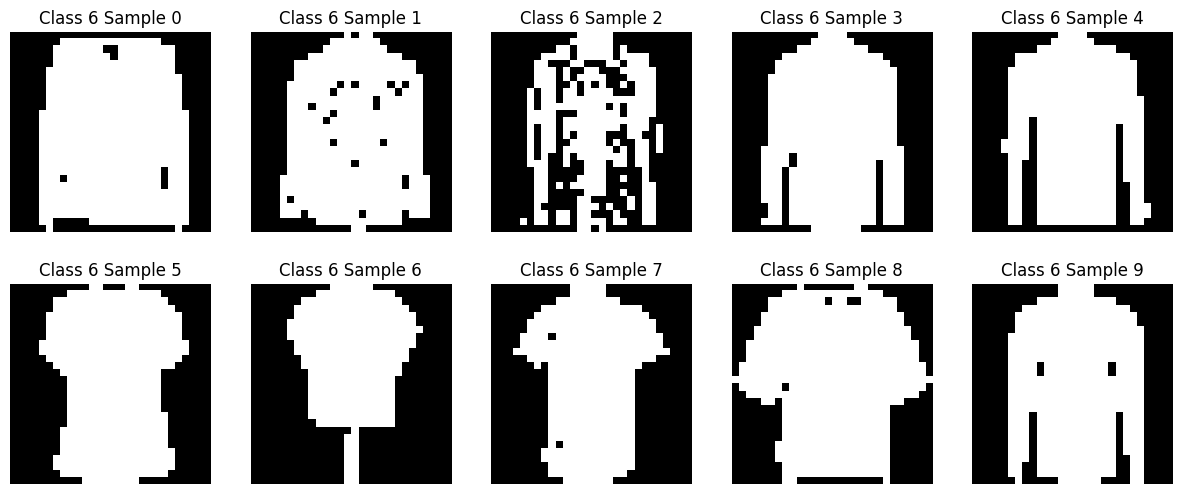

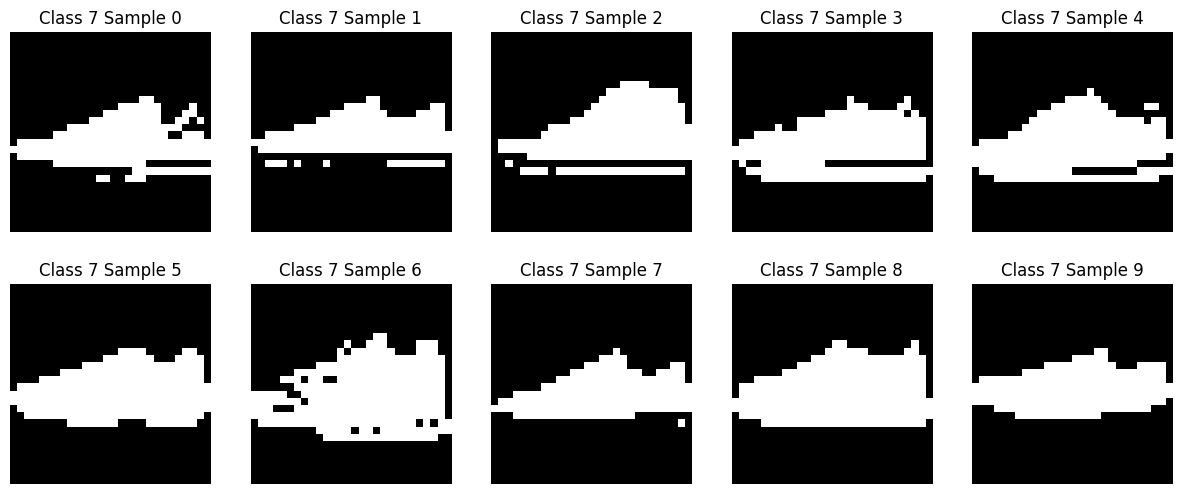

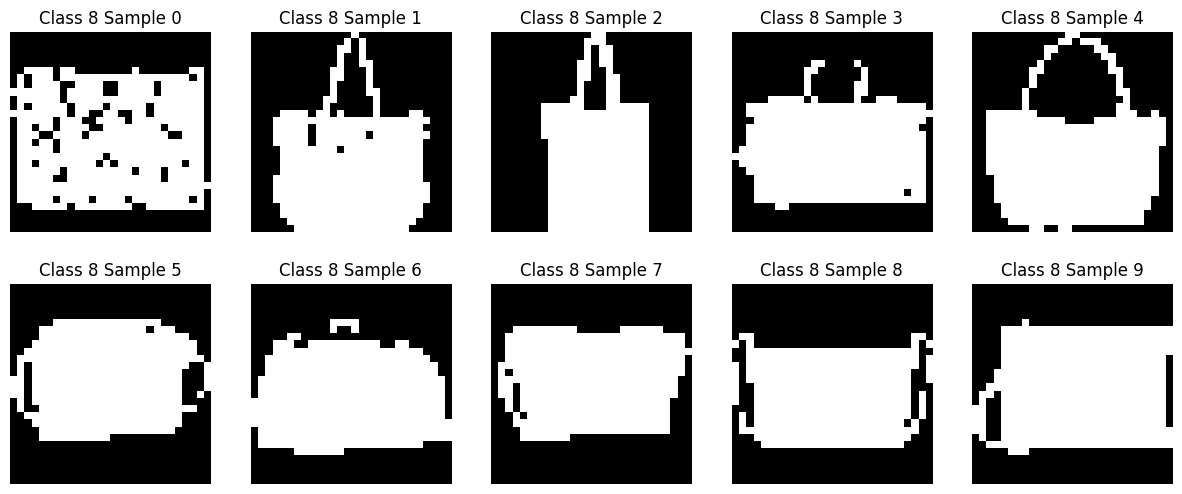

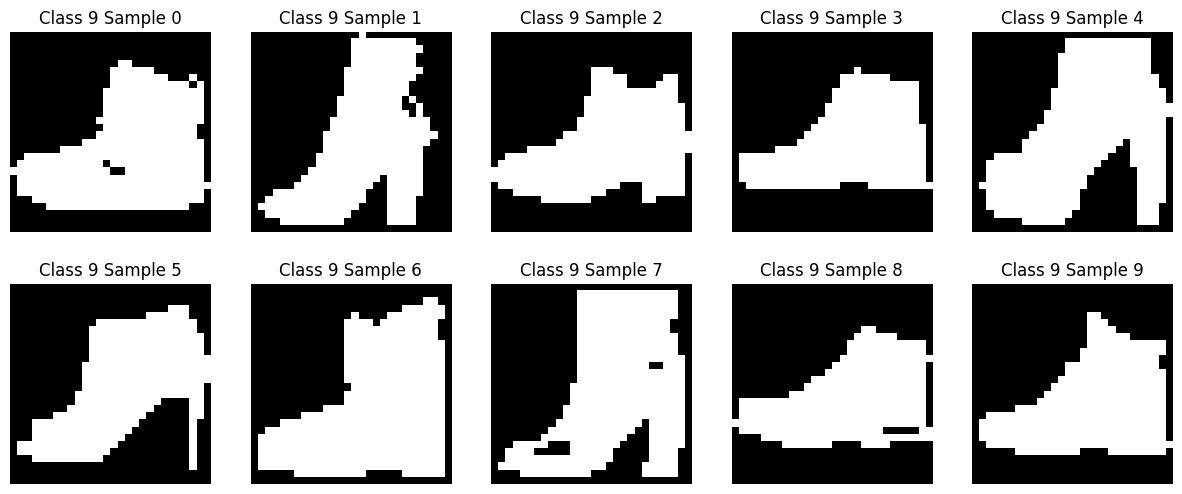

In [129]:
# For all classes in train dataset, average the images and plot them
num_classes = train_labels.max().item() + 1

# Relative-based thresholding
threshold_relative = 1.0 # This is a relative threshold multiplier relative to the average intensity of the image

# Absolute-based thresholding
threshold_absolute = 0.5 # This is an absolute threshold value between 0 and 1

mode = 'relative'
if mode == 'relative':
    for i in range(len(train_data)):
        image = train_data[i]

        # Ensure that image has shape 28x28
        if image.ndim != 2:
            if image.ndim == 3:
                image = image.mean(dim=0)

        avg_intensity = image.mean().item()
        threshold_value = threshold_relative * avg_intensity
        train_data[i] = (image > threshold_value).float()
else:
    for i in range(len(train_data)):
        image = train_data[i]
        train_data[i] = (image > threshold_absolute).float()

avg_images = []
for c in range(num_classes):
    class_images = train_data[train_labels == c]
    
    # If the second dimension is not 1, take the mean across that dimension
    if class_images.shape[1] == 3:
        class_images = class_images.mean(dim=1, keepdim=True)
    elif class_images.shape[1] > 3:
        # Take the first, last, and middle slice
        middle_idx = class_images.shape[1] // 2
        class_images = class_images[:, [0, middle_idx, -1], :, :]

        # Then take the mean across that dimension
        class_images = class_images.mean(dim=1, keepdim=True)

    avg_image = class_images.mean(dim=0)
    avg_images.append(avg_image)

# Plot average images
fig, axs = plt.subplots(1, num_classes, figsize=(15, 5))
for c in range(num_classes):
    axs[c].imshow(avg_images[c].squeeze(), cmap='gray')
    axs[c].set_title(f'Class {c}')
plt.show()

# For each class, plot 10 sample images
for c in range(num_classes):
    class_images = train_data[train_labels == c]
    fig, axs = plt.subplots(2, 5, figsize=(15, 6))
    for i in range(10):
        ax = axs[i // 5, i % 5]

        image = class_images[i]

        image = image.squeeze()
        # if it has 3 channels, take the mean across channels
        if image.ndim != 2:
            image = image.mean(dim=0)
        ax.imshow(image, cmap='gray')
        ax.set_title(f'Class {c} Sample {i}')
        ax.axis('off')
    plt.show()

In [130]:
# Use Linear regression on the first 1,000 images to obtain a baseline accuracy
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
X_train = train_data[:1000].view(1000, -1).numpy()
y_train = train_labels[:1000].numpy()

logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train, y_train)

# Predict on next 1,000 images
X_test = train_data[1000:2000].view(1000, -1).numpy()
y_test = train_labels[1000:2000].numpy()

y_pred = logreg.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Baseline accuracy on second 1000 training samples: {accuracy*100:.2f}%')

Baseline accuracy on second 1000 training samples: 79.80%
